# ---------------------------
# PART 1: Anomaly Detection - Credit Card Fraud Detection
# ---------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# Load fraud detection dataset
df_fraud = pd.read_csv("creditcard.csv")

In [3]:
# Feature scaling
scaler = StandardScaler()
df_fraud[['scaled_time', 'scaled_amount']] = scaler.fit_transform(df_fraud[['Time', 'Amount']])
df_fraud_model = df_fraud.drop(['Time', 'Amount'], axis=1)
df_fraud_model['Time'] = df_fraud['scaled_time']
df_fraud_model['Amount'] = df_fraud['scaled_amount']

In [38]:
# Anomaly Detection using Isolation Forest
X = df_fraud_model.drop(columns='Class')
y = df_fraud_model['Class']

iso_model = IsolationForest(n_estimators=1000, contamination=0.0017, random_state=42)
iso_model.fit(X)

df_fraud_model['anomaly'] = iso_model.predict(X)
df_fraud_model['anomaly'] = df_fraud_model['anomaly'].map({1: 0, -1: 1})

print("Confusion Matrix:")
print(confusion_matrix(y, df_fraud_model['anomaly']))
print("\nClassification Report:")
print(classification_report(y, df_fraud_model['anomaly'], digits=4))


Confusion Matrix:
[[283943    372]
 [   379    113]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987    284315
           1     0.2330    0.2297    0.2313       492

    accuracy                         0.9974    284807
   macro avg     0.6158    0.6142    0.6150    284807
weighted avg     0.9973    0.9974    0.9974    284807



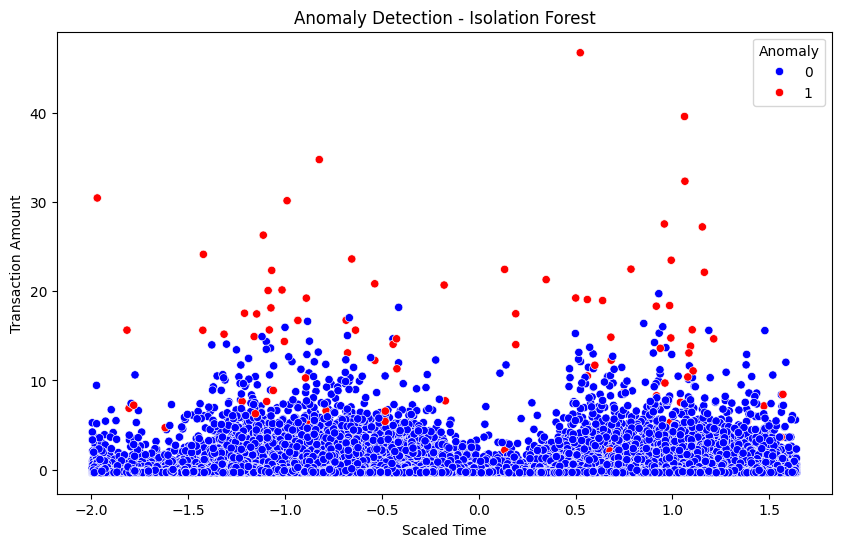

In [39]:
# Plot anomalies
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fraud_model.sample(100000), x='Time', y='Amount', hue='anomaly', palette={0: 'blue', 1: 'red'})
plt.title("Anomaly Detection - Isolation Forest")
plt.xlabel("Scaled Time")
plt.ylabel("Transaction Amount")
plt.legend(title='Anomaly')
plt.show()


# ---------------------------
# PART 2: Customer Profiling - KMeans Clustering from Scratch
# ---------------------------

In [6]:
from copy import deepcopy

In [8]:
# Load customer data
df_customer = pd.read_csv("customerdata.csv")  # Replace with your local file
df_cluster = df_customer.drop(columns=["Sl_No", "Customer Key"])
df_cluster.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


In [9]:
# Normalize
scaler = StandardScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_cluster), columns=df_cluster.columns)
data_np = df_normalized.to_numpy()


In [10]:
# Euclidean distance
def euclidean(a, b):
    return np.linalg.norm(a - b)


In [11]:
# KMeans from scratch
def kmeans(data, k, max_iters=100):
    np.random.seed(42)
    n_samples, n_features = data.shape
    centroids = data[np.random.choice(n_samples, k, replace=False)]

    for _ in range(max_iters):
        clusters = [[] for _ in range(k)]
        for idx, point in enumerate(data):
            distances = [euclidean(point, centroid) for centroid in centroids]
            cluster_idx = np.argmin(distances)
            clusters[cluster_idx].append(idx)

        new_centroids = np.zeros((k, n_features))
        for idx, cluster in enumerate(clusters):
            if cluster:
                new_centroids[idx] = np.mean(data[cluster], axis=0)
            else:
                new_centroids[idx] = data[np.random.choice(n_samples)]

        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    labels = np.empty(n_samples)
    for cluster_idx, cluster in enumerate(clusters):
        for sample_idx in cluster:
            labels[sample_idx] = cluster_idx
    return centroids, labels

In [12]:
# Elbow method
inertia_scores = []
K_range = range(1, 11)
for k in K_range:
    centroids, labels = kmeans(data_np, k)
    inertia = 0
    for i in range(len(data_np)):
        inertia += euclidean(data_np[i], centroids[int(labels[i])]) ** 2
    inertia_scores.append(inertia)

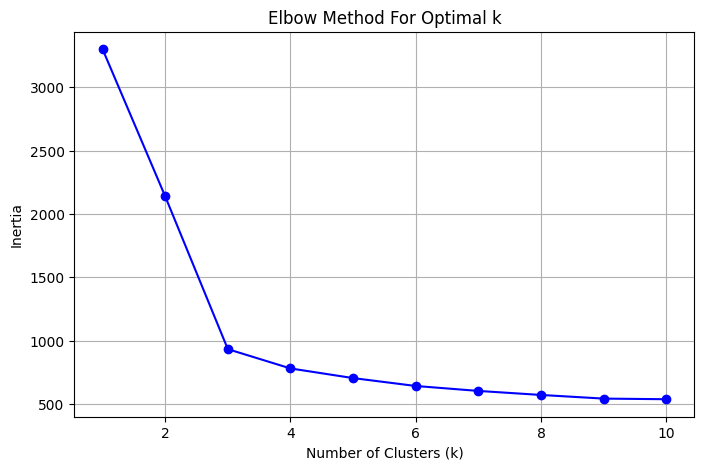

In [13]:
# Plot Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [30]:
# Final Clustering with k=3
final_centroids, final_labels = kmeans(data_np, 3)
df_customer['Cluster'] = final_labels.astype(int)
print(df_customer[['Avg_Credit_Limit', 'Cluster']].groupby('Cluster').mean())


         Avg_Credit_Limit
Cluster                  
0           141040.000000
1            33782.383420
2            12174.107143


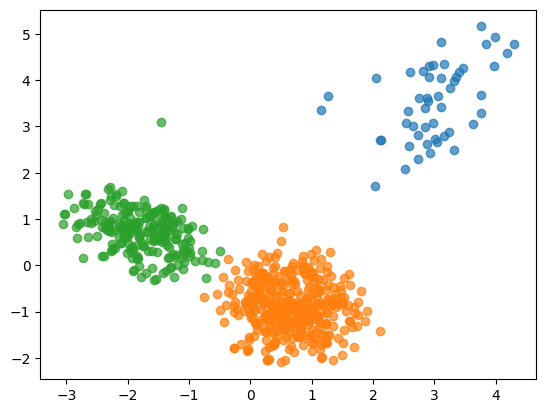

In [31]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data_np)
df_customer['PCA1'] = reduced_data[:, 0]
df_customer['PCA2'] = reduced_data[:, 1]

for cluster in range(4):
    plt.scatter(df_customer[df_customer['Cluster'] == cluster]['PCA1'],
                df_customer[df_customer['Cluster'] == cluster]['PCA2'],
                label=f"Cluster {cluster}", alpha=0.7)

# ---------------------------
# PART 3: Linear Regression - Predict Avg_Credit_Limit
# ---------------------------

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
X = df_cluster.drop(columns='Avg_Credit_Limit')
y = df_cluster['Avg_Credit_Limit']

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("\nLinear Regression Results:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))


Linear Regression Results:
Mean Squared Error: 538721153.8254908
R^2 Score: 0.5930299734705842


In [19]:
# Show coefficients
features = list(X.columns)
coefficients = lr_model.coef_
for f, c in zip(features, coefficients):
    print(f"{f}: {c:.2f}")


Total_Credit_Cards: 7225.01
Total_visits_bank: -2390.32
Total_visits_online: 6138.47
Total_calls_made: -3439.42
